In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from waymo_agent import *

In [3]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [4]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from kret_sandbox.VIS import dtt

#### Load ENV

In [5]:
def get_obvs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides

In [6]:
envconfig = EnvConfig()
cfg = envconfig

In [7]:
env = RideShareEnv(cfg)
G = env.graph

Assigned lambda values to nodes. Total lambda: 2.2551 (target: 2.3460)


/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


[0.99906443 0.03       0.003     ] (3,)


In [8]:
s, info = env.reset()

[0.99998227 0.03       0.003     ] (3,)


/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


In [9]:
SupplyDemandDF.space_config(envconfig)["shape"]

(3,)

In [10]:
BASE_CLASS_ATTRS = set(vars(EnrichedDF).keys())
BASE_CLASS_ATTRS

{'__annotations__',
 '__doc__',
 '__module__',
 'calc_width',
 'cols_to_pass_to_model',
 'column_order',
 'default_vals',
 'f_valid',
 'from_obs_numpy',
 'generate_empty',
 'space_config',
 'target_dtypes',
 'to_obs_numpy',
 'to_training_df',
 'validate_dtypes'}

In [11]:
action = env.action_space.sample()

In [12]:
# obs, reward, terminated, truncated, info = env.step(action)

In [13]:
veh, req, rides = get_obvs_tuple(env)

In [14]:
from waymo_agent.data_classes.supply_demand_df import SupplyDemandDF


get_sd_ratio(cfg, req, veh)[0]

np.float64(0.9999822711311133)

In [15]:
dtt([veh, rides], cols_per_row=1)

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 3 
 3 
 -0.374 
 0.065 
 0.952 
 0 
 -1 
 
 
 4 
 4 
 0.556 
 0.437 
 0.934 
 0 
 -1 
 
 
 6 
 6 
 -0.328 
 0.042 
 0.847 
 0 
 -1 
 
 
 8 
 8 
 -0.028 
 0.135 
 0.627 
 0 
 -1 
 
 
 12 
 12 
 -0.073 
 0.154 
 0.651 
 0 
 -1 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 3 
 -1 
 3 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 4 
 -1 
 4 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 6 
 -1 
 6 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 8 
 -1 
 8 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 12 
 -1 
 12 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False

In [16]:
ven, reqn, ridesn = get_obvs_tuple(env)

In [17]:
dtt([ven, reqn, ridesn], cols_per_row=1)

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 6 
 6 
 -0.328 
 0.042 
 0.847 
 0 
 -1 
 
 
 13 
 13 
 0.240 
 0.022 
 0.766 
 0 
 -1 
 
 
 14 
 14 
 0.242 
 0.585 
 0.771 
 0 
 -1 
 
 
 19 
 19 
 0.076 
 -0.566 
 0.842 
 0 
 -1 
 
 
 20 
 20 
 0.202 
 0.193 
 0.789 
 0 
 -1 
 
 
 
 
 
 
 request_id 
 request_dt 
 cust_id 
 cust_bias 
 cust_temperature 
 est_cost 
 price 
 max_wait_time 
 wait_time 
 status 
 pickup_node_id 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node_id 
 dropoff_x_norm 
 dropoff_y_norm 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 distance_meters 
 
 
 
 
 13 
 -1 
 NaT 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 -1.0 
 
 
 30 
 -1 
 NaT 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 -1.0 
 
 
 31 
 -1 
 NaT 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 -1.0 
 
 
 39 
 -1 
 NaT 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 -1.0 
 
 
 46 
 -1 
 NaT 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 -1.0 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 6 
 -1 
 6 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 13 
 -1 
 13 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 14 
 -1 
 14 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 19 
 -1 
 19 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 20 
 -1 
 20 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False

In [18]:
fig, ax = env.render()

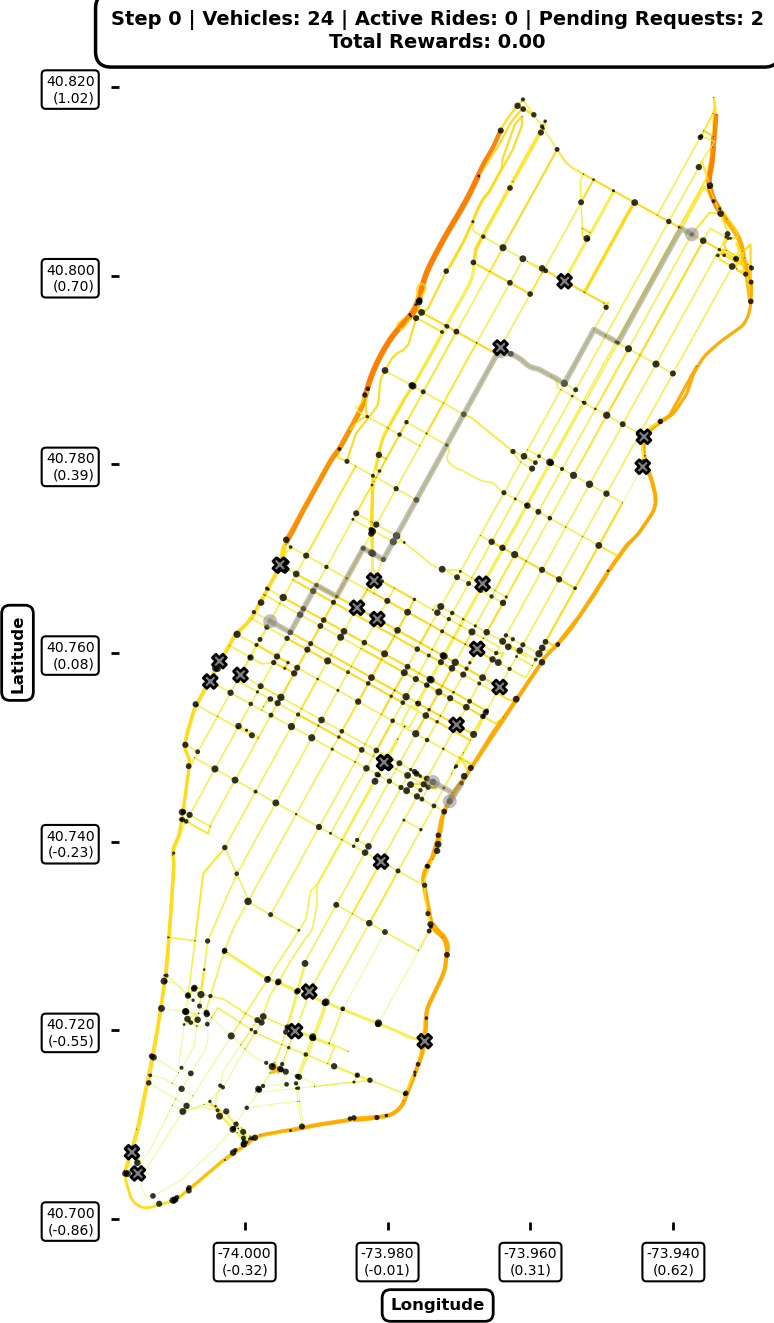

In [20]:
fig

In [21]:
out = env.step(action)

/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


In [22]:
fig, ax = env.render()

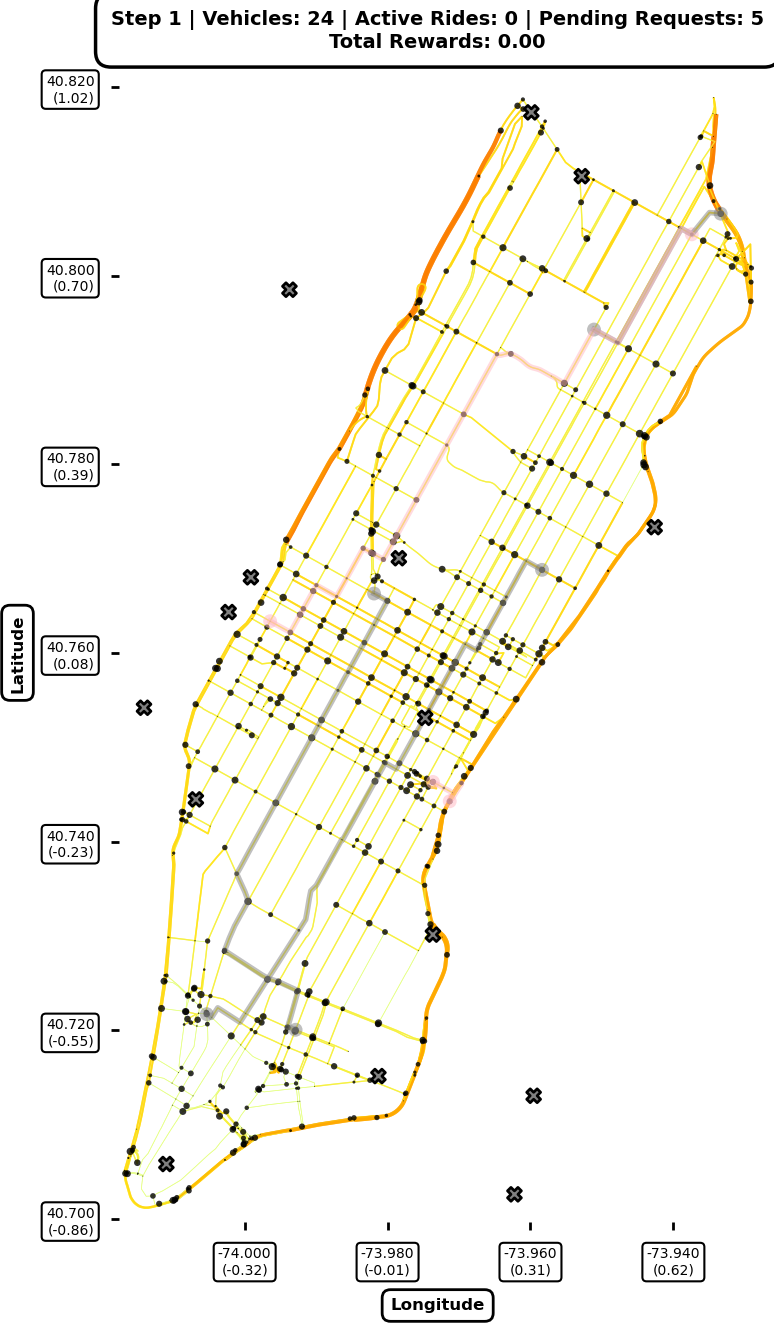

In [23]:
fig